# <font color='#FFE15D'>**Week 3: Multiple Linear Regression 📈**</font>

## **🔸 Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import sklearn
# from sklearn import linear_model
from sklearn.linear_model import LinearRegression, SGDRegressor

## **🔸 Data**

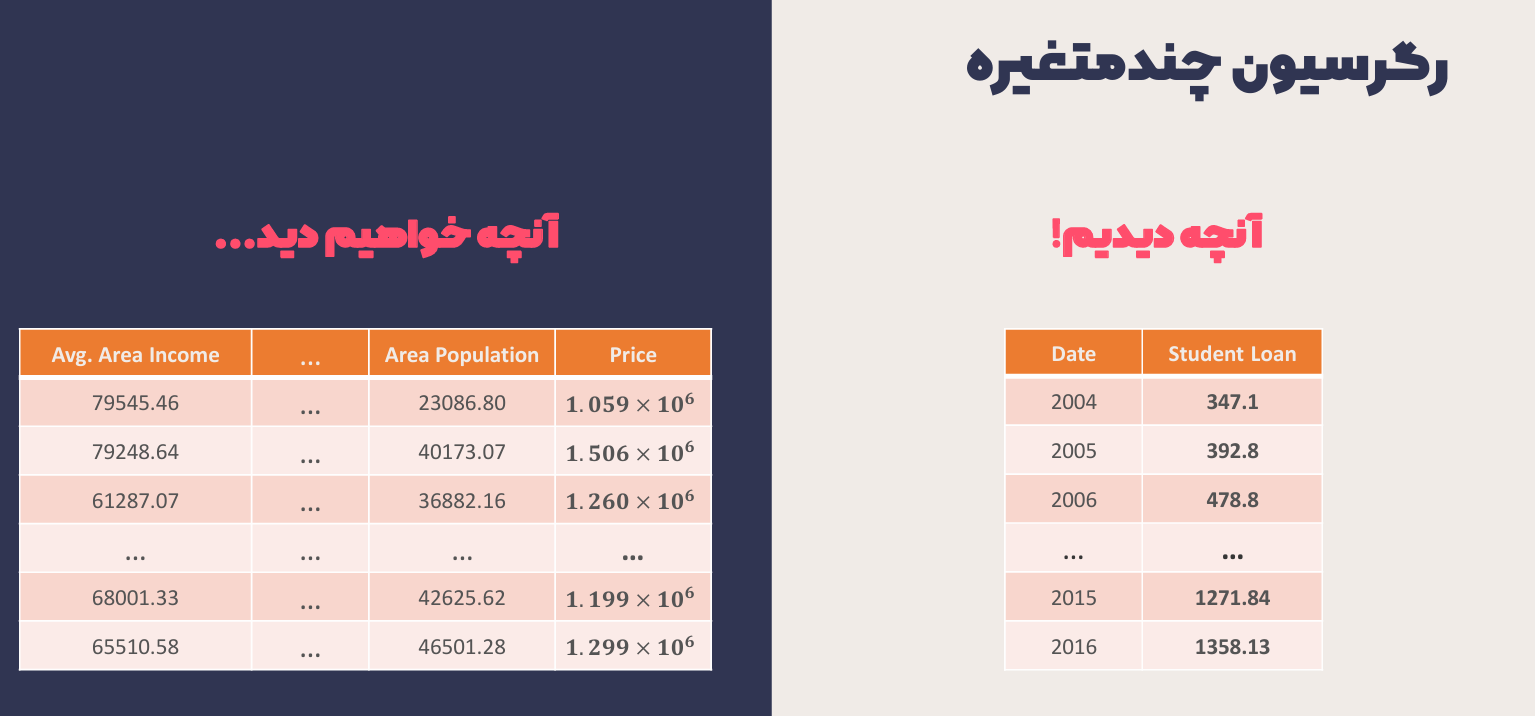

### Load data

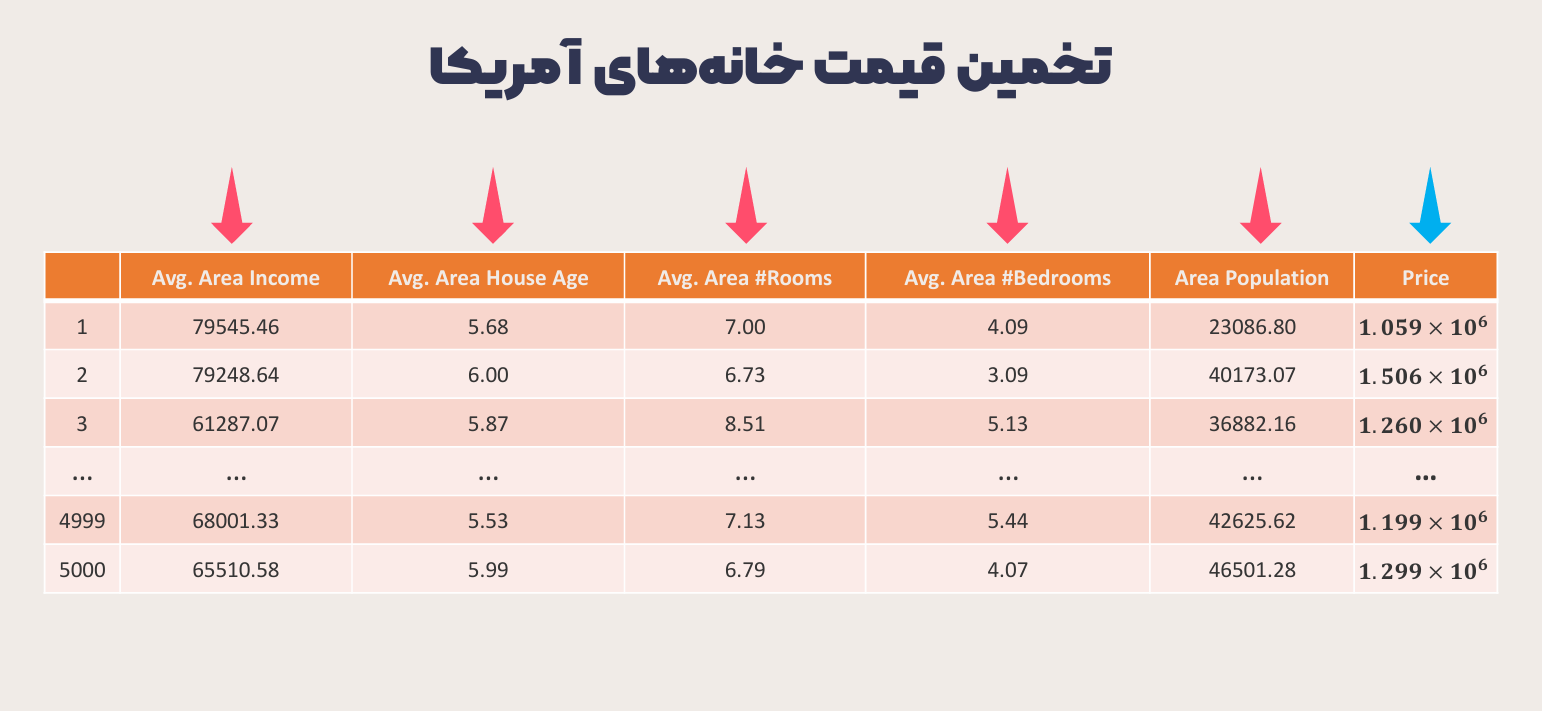

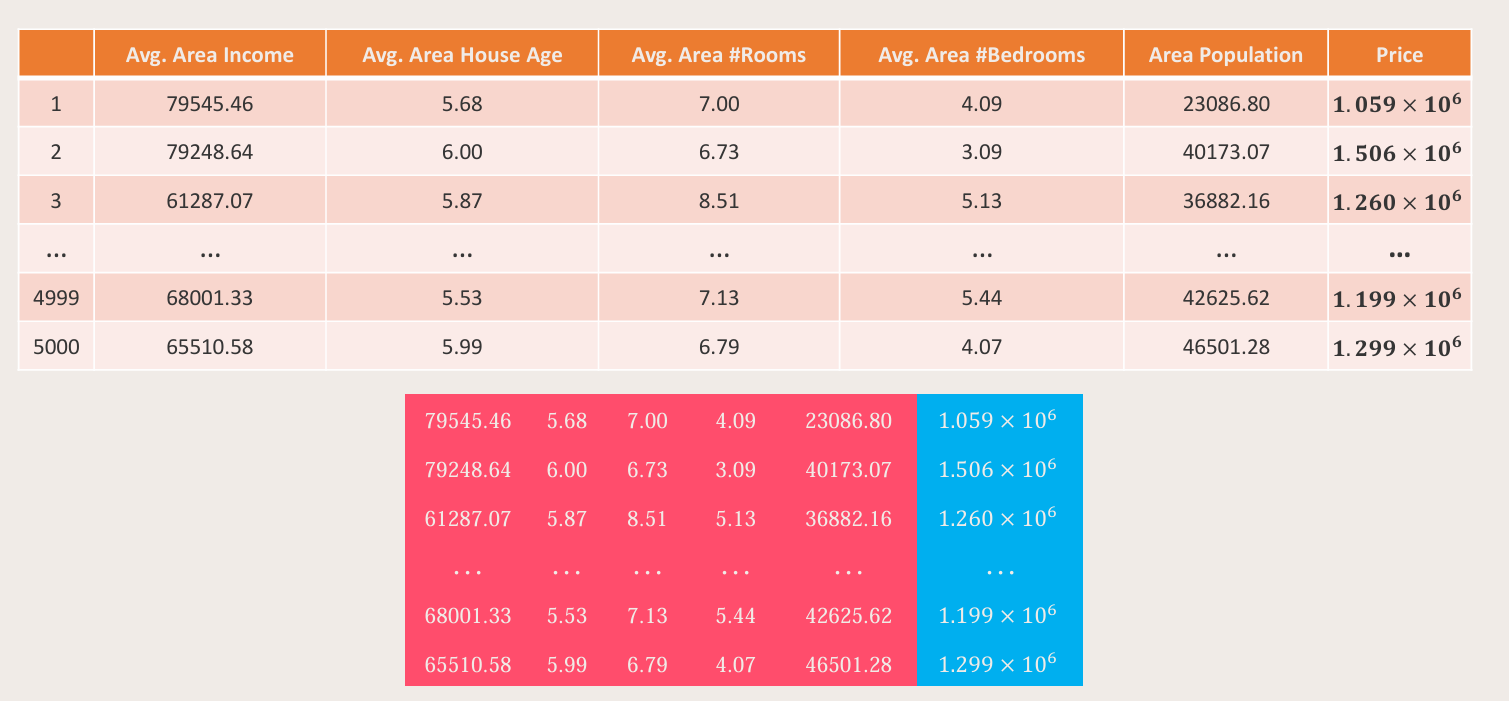

In [2]:
df = pd.read_csv('data/usa-housing-train-preprocessed.csv')
df

,Unnamed: 0,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,0,-1.251559,-2.029014,1.962066,0.323068,0.745056,0.881446
1,1,-0.589051,0.518025,0.655811,-0.641265,1.098587,1.375771
2,2,0.822222,-0.574674,1.248231,-0.706094,-0.952839,1.137069
3,3,-0.256822,0.411710,-0.182614,-0.649369,-0.800950,0.928950
4,4,0.072036,0.941329,1.292845,0.250135,0.062022,1.392084
...,...,...,...,...,...,...,...
3495,3495,0.716947,0.397844,-1.636195,-1.265245,-0.604371,1.023944
3496,3496,-1.116466,0.989374,0.511392,-0.487296,0.721300,1.223101
3497,3497,-0.224058,0.535377,-0.373788,-0.681783,0.113395,1.318598
3498,3498,-0.927903,1.429905,2.268655,0.274446,1.390220,1.708631


In [3]:
df.columns

Index(['Unnamed: 0', 'Avg. Area Income', 'Avg. Area House Age',
       'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms',
       'Area Population', 'Price'],
      dtype='object')

### Split x & y

In [4]:
train_set = np.array(df)[:, 1:]
x_train = train_set[:, 0:5]
y_train = train_set[:, 5]
x_train.shape, y_train.shape

((3500, 5), (3500,))

In [5]:
x_train   

array([[-1.25155908, -2.02901391,  1.96206583,  0.32306769,  0.74505618],
       [-0.58905082,  0.51802457,  0.65581093, -0.64126509,  1.09858717],
       [ 0.82222246, -0.5746743 ,  1.24823096, -0.70609418, -0.95283943],
       ...,
       [-0.22405818,  0.53537657, -0.37378791, -0.68178327,  0.1133951 ],
       [-0.92790309,  1.4299047 ,  2.26865538,  0.27444587,  1.39022039],
       [-0.69631047, -0.08161155,  0.88764104,  1.6682714 , -0.01308001]])

In [6]:
y_train

array([0.88144612, 1.37577113, 1.13706931, ..., 1.31859771, 1.70863137,
       1.06089769])

### Visualize

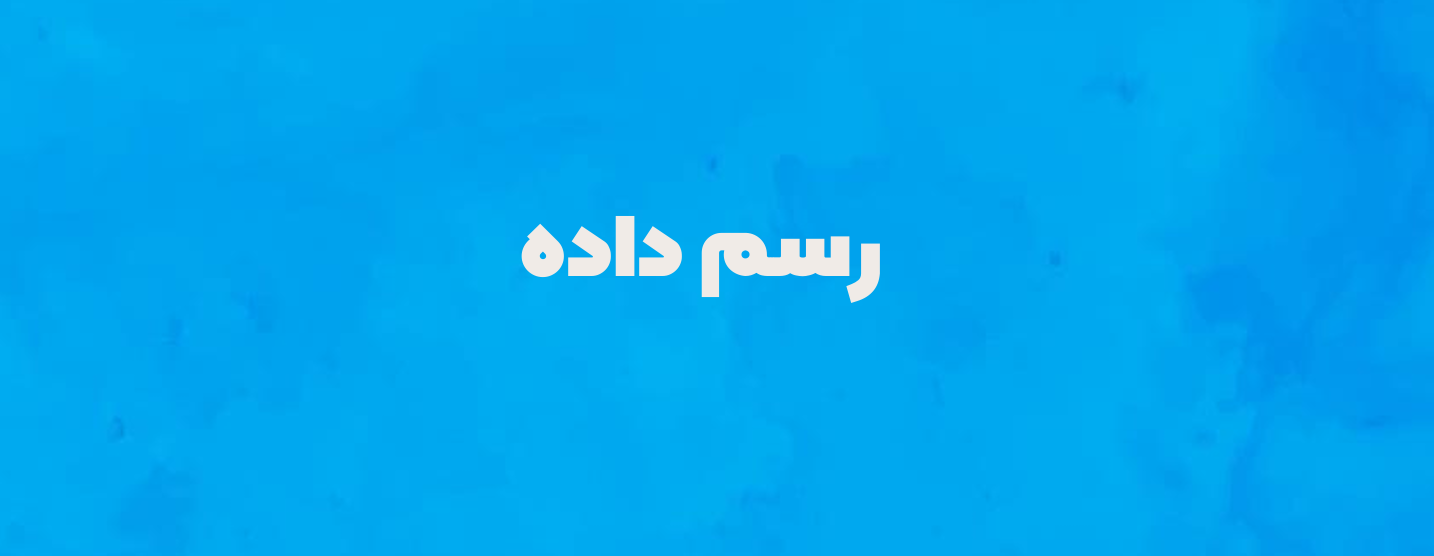

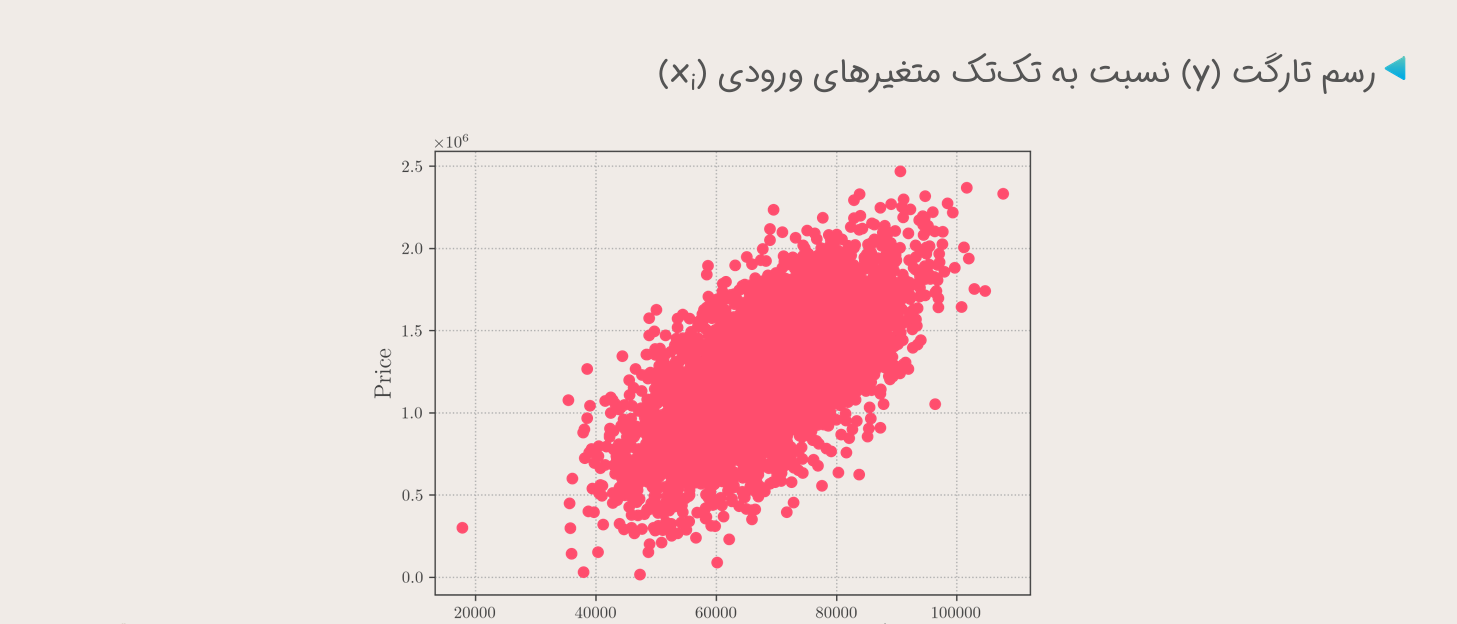

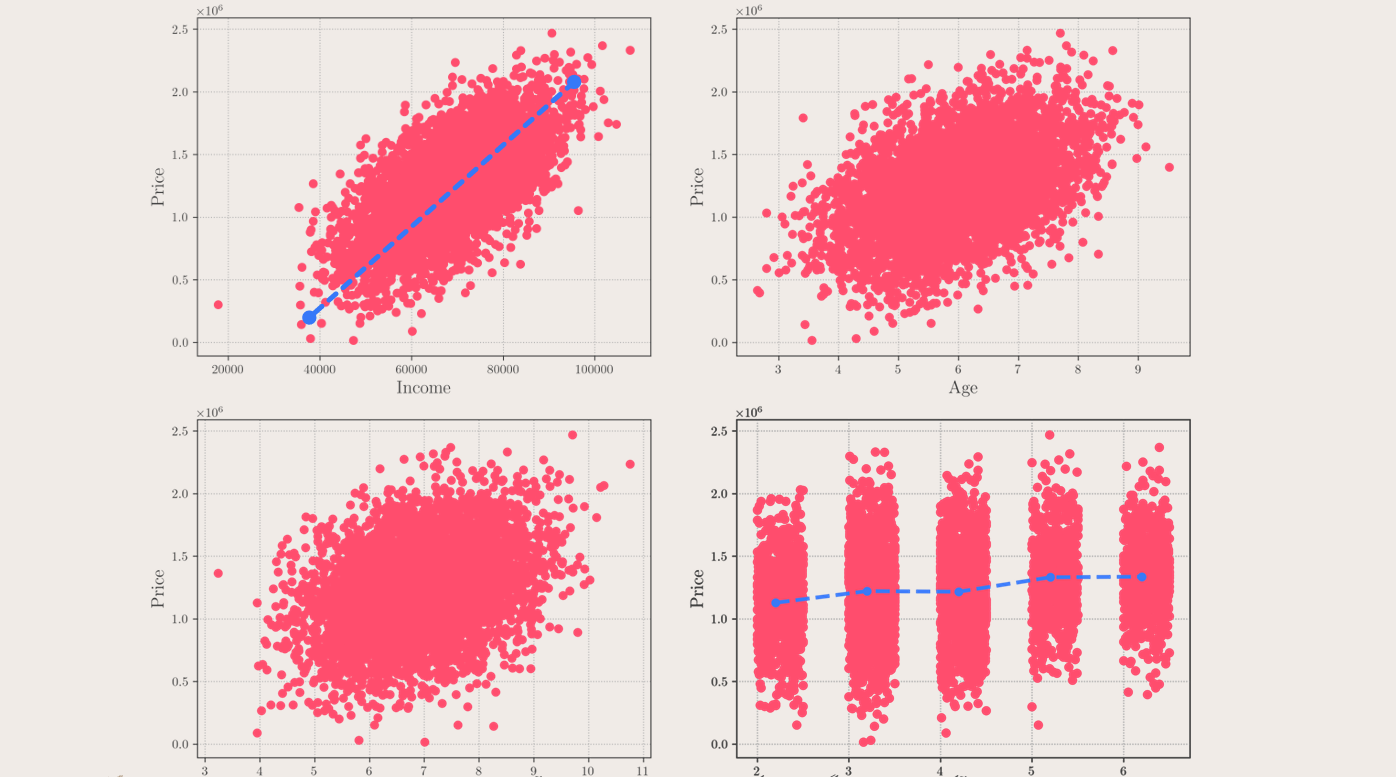

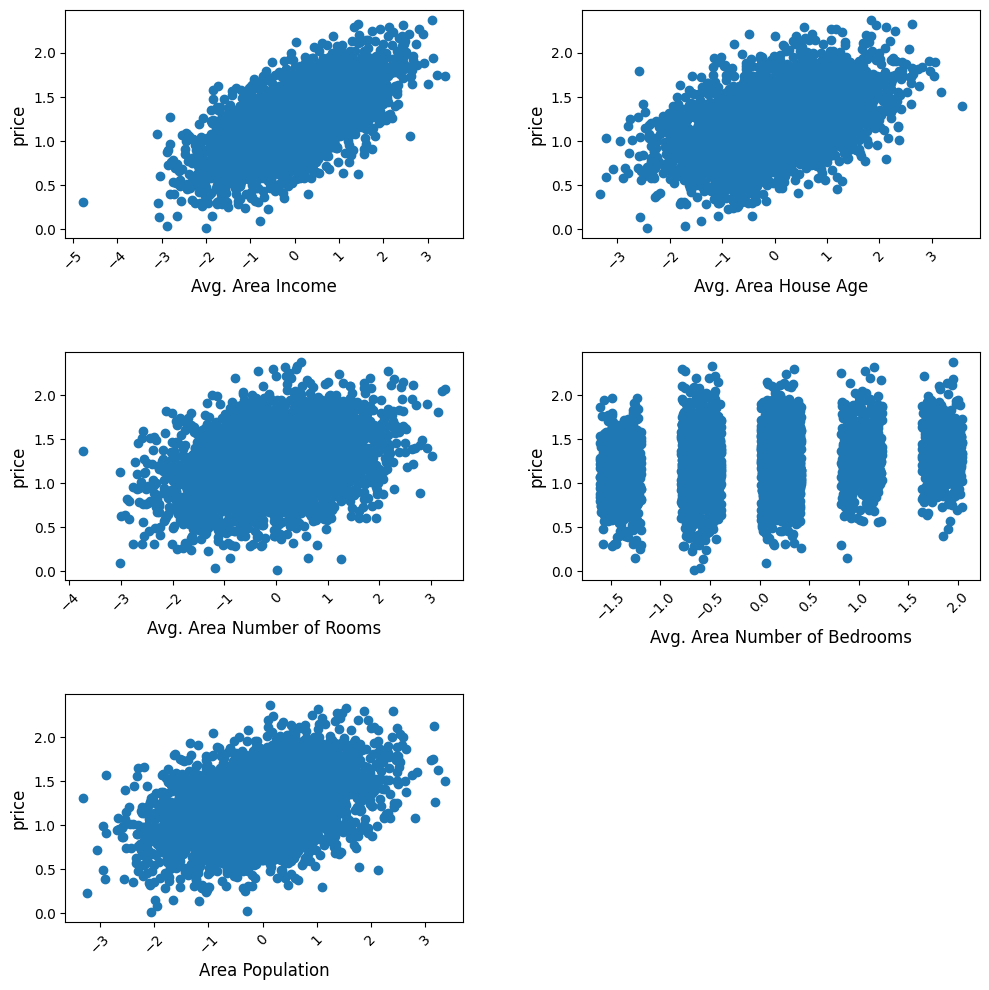

In [7]:
fig = plt.figure(figsize=(10, 10))
plt1 = fig.add_subplot(321)
plt2 = fig.add_subplot(322)
plt3 = fig.add_subplot(323)
plt4 = fig.add_subplot(324)
plt5 = fig.add_subplot(325)

plt1.scatter(x_train[:, 0], y_train)  
plt1.tick_params(axis='x', rotation=45)
plt1.set_xlabel('Avg. Area Income', fontsize=12)       
plt1.set_ylabel('price', fontsize=12)

plt2.scatter(x_train[:, 1], y_train)
plt2.tick_params(axis='x', rotation=45)
plt2.set_xlabel('Avg. Area House Age', fontsize=12)       
plt2.set_ylabel('price', fontsize=12)       

plt3.scatter(x_train[:, 2], y_train)
plt3.tick_params(axis='x', rotation=45)
plt3.set_xlabel('Avg. Area Number of Rooms', fontsize=12)       
plt3.set_ylabel('price', fontsize=12)

plt4.scatter(x_train[:, 3], y_train)
plt4.tick_params(axis='x', rotation=45)
plt4.set_xlabel('Avg. Area Number of Bedrooms', fontsize=12)       
plt4.set_ylabel('price', fontsize=12)

plt5.scatter(x_train[:, 4], y_train)
plt5.tick_params(axis='x', rotation=45)
plt5.set_xlabel('Area Population', fontsize=12)       
plt5.set_ylabel('price', fontsize=12)


plt.tight_layout()
plt.subplots_adjust(wspace=0.3,hspace=0.5)
plt.show()   

## **🔸 Model**

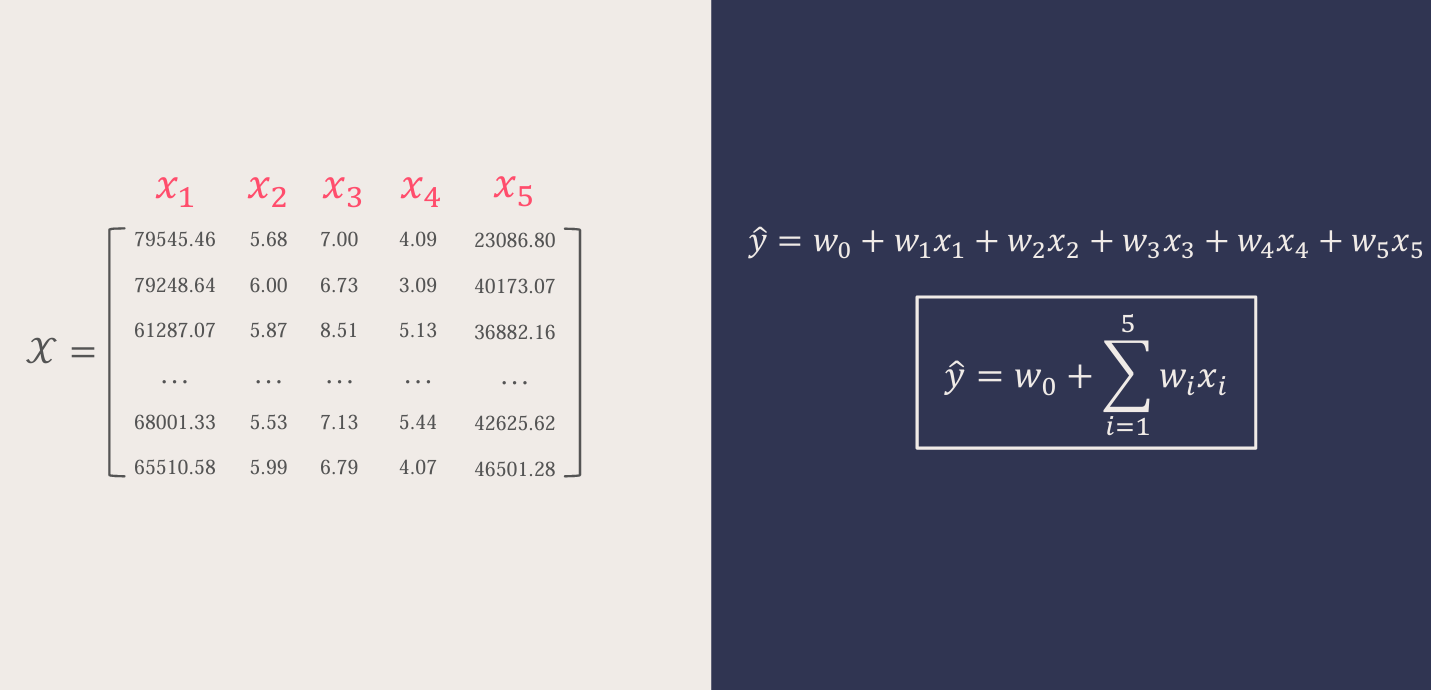

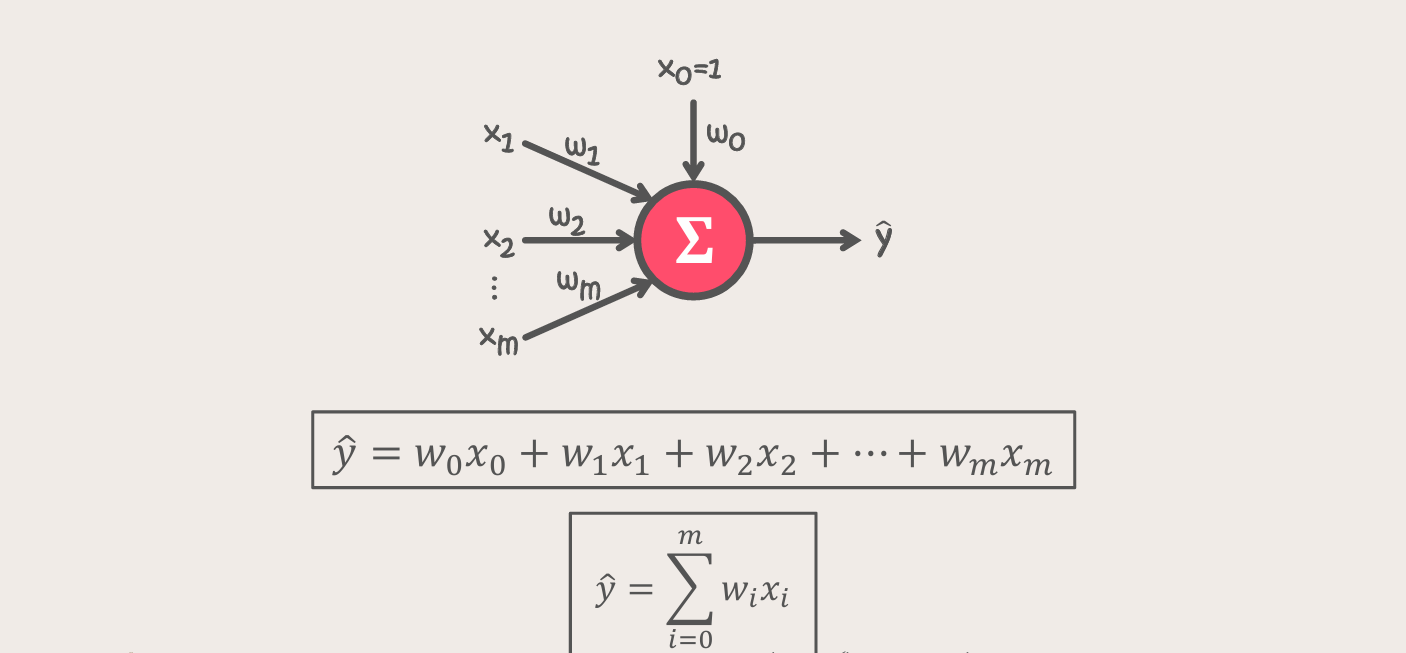

In [8]:
# n, m = x_train.shape

# x_train_aug = np.hstack((np.ones((n, 1)), x_train))
# print(x_train_aug)
# print(x_train_aug.shape)

# print('*' * 80)

# print(x_train_aug.T)

# print('*' * 80)

# w = np.random.randn(m+1)
# print(f'w: {w}')

# y_hat = 0
# for xi, wi in zip(x_train_aug.T, w):
#     y_hat += xi*wi
  
# print()  
# print(f'y_hat: {y_hat}, \ny_hat.shape: {y_hat.shape}' )

## **🔸 Vectorization**

<img src="imgs/train-vec.png" alt="string indexing" width=500 align="center" />     <img src="imgs/test-vec.png" alt="string indexing" width=250 align="center" />

### Functions

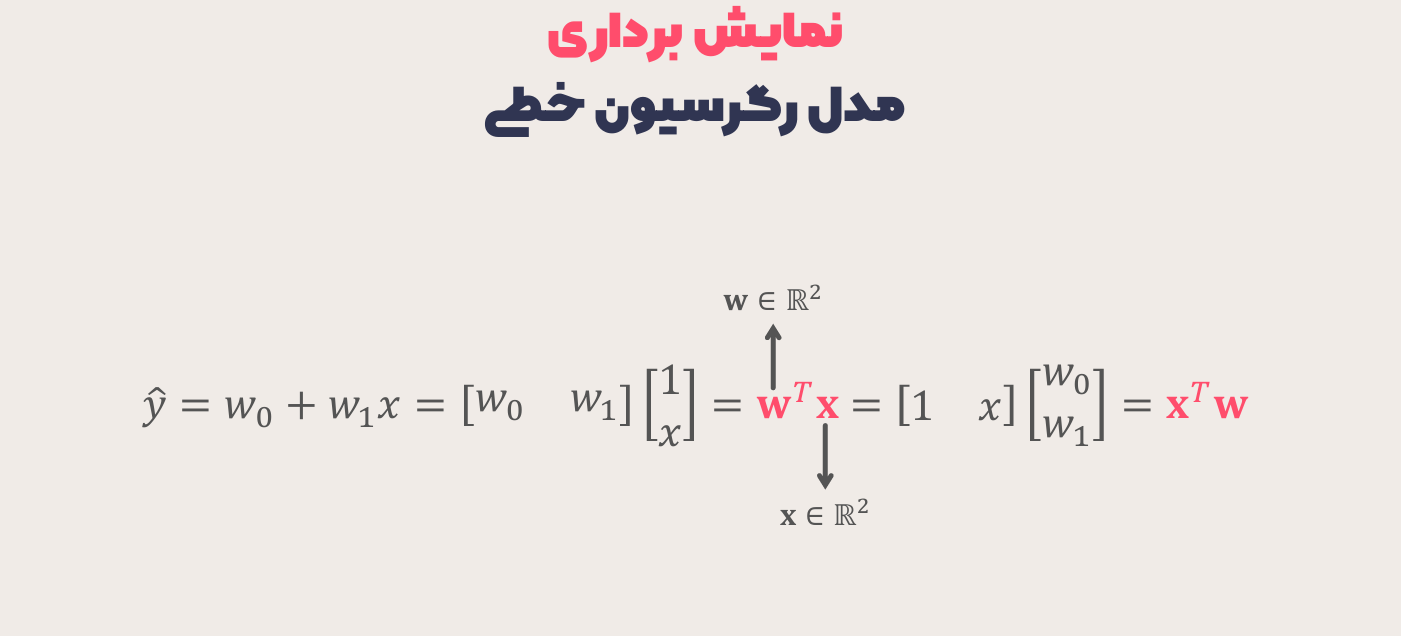

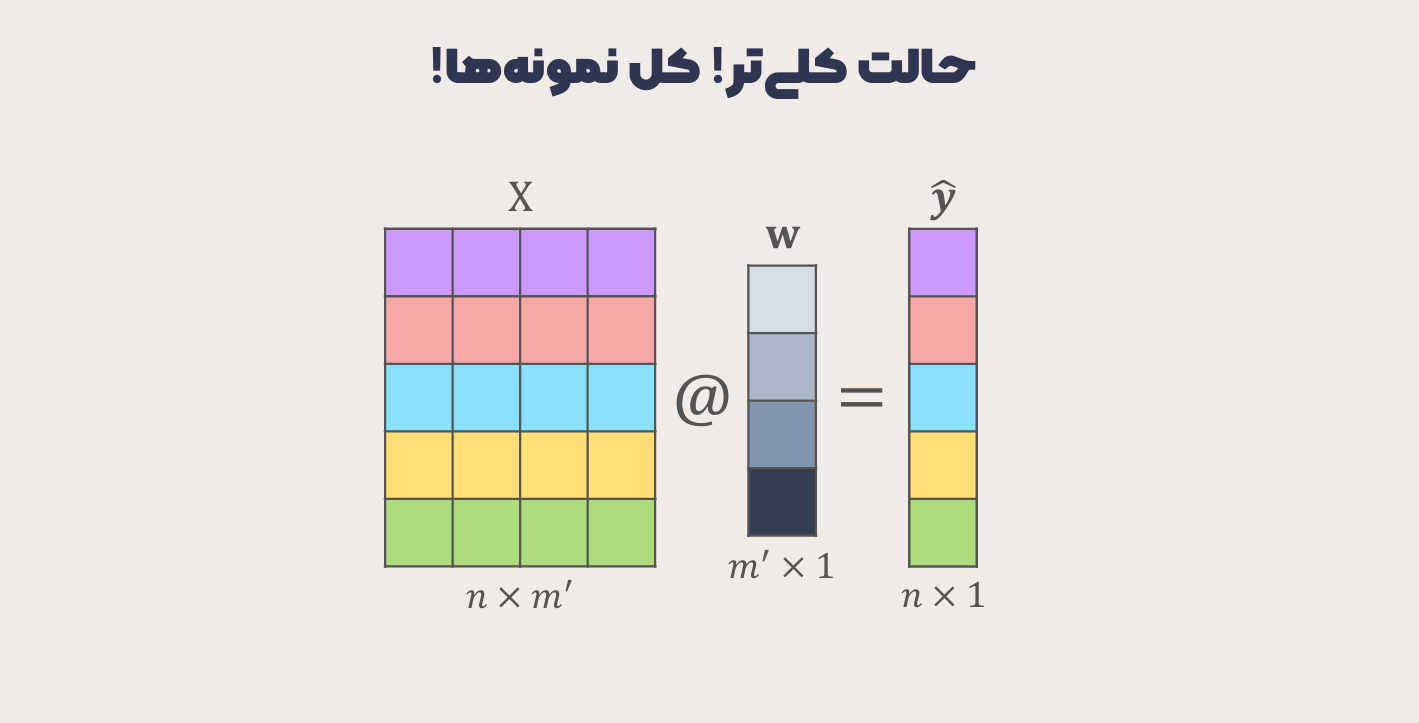

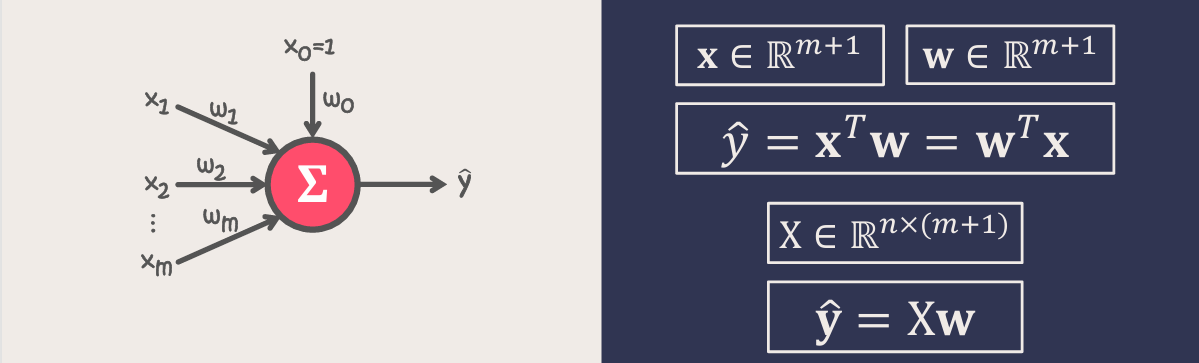

In [9]:
def multiple_linear_regression(x, w):
    y_hat = x @ w
    return y_hat

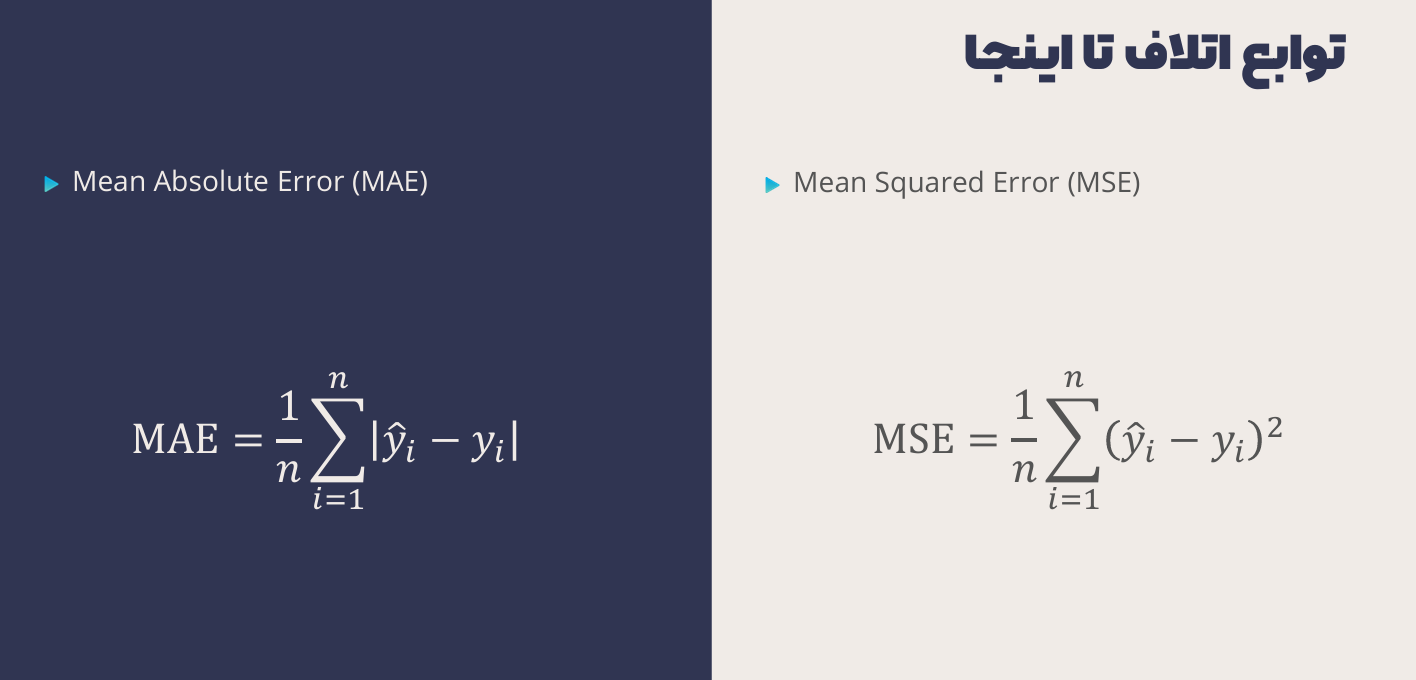

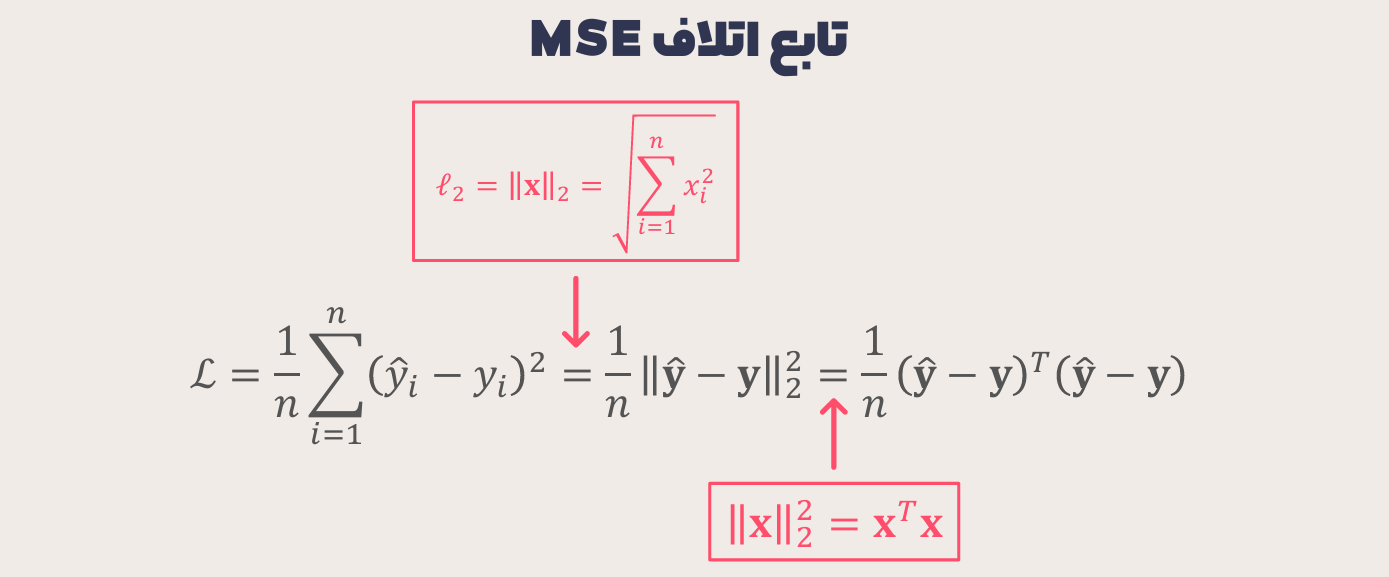

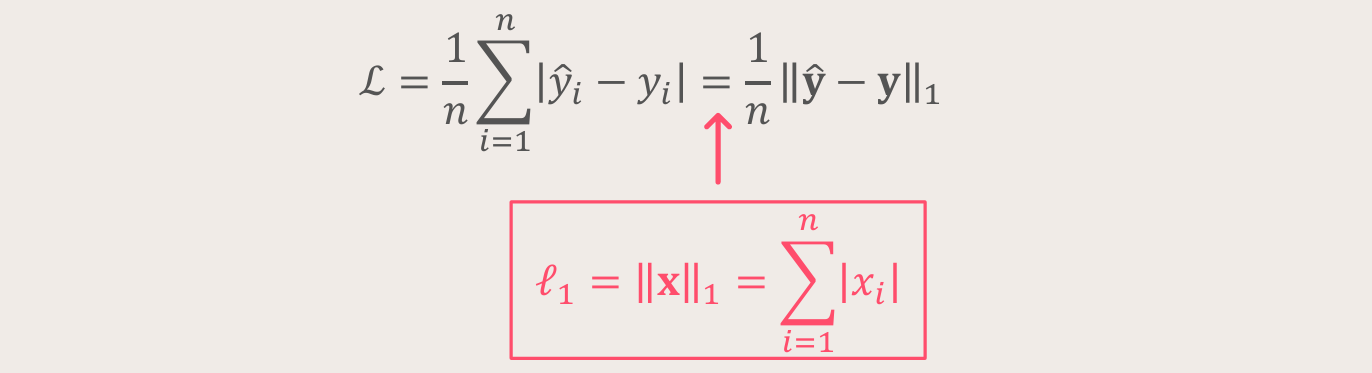

In [10]:
def mse(y, y_hat):
    loss = np.mean((y - y_hat)**2)
    return loss # np.linalg.norm(y-y_hat)**2 / len(y), ((y_hat - y).T @ (y_hat - y)) / len(y)

In [11]:
def mae(y, y_hat):
    loss = np.mean(np.abs(y - y_hat))
    return loss

In [12]:
def r2(y, y_hat):
    return 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)

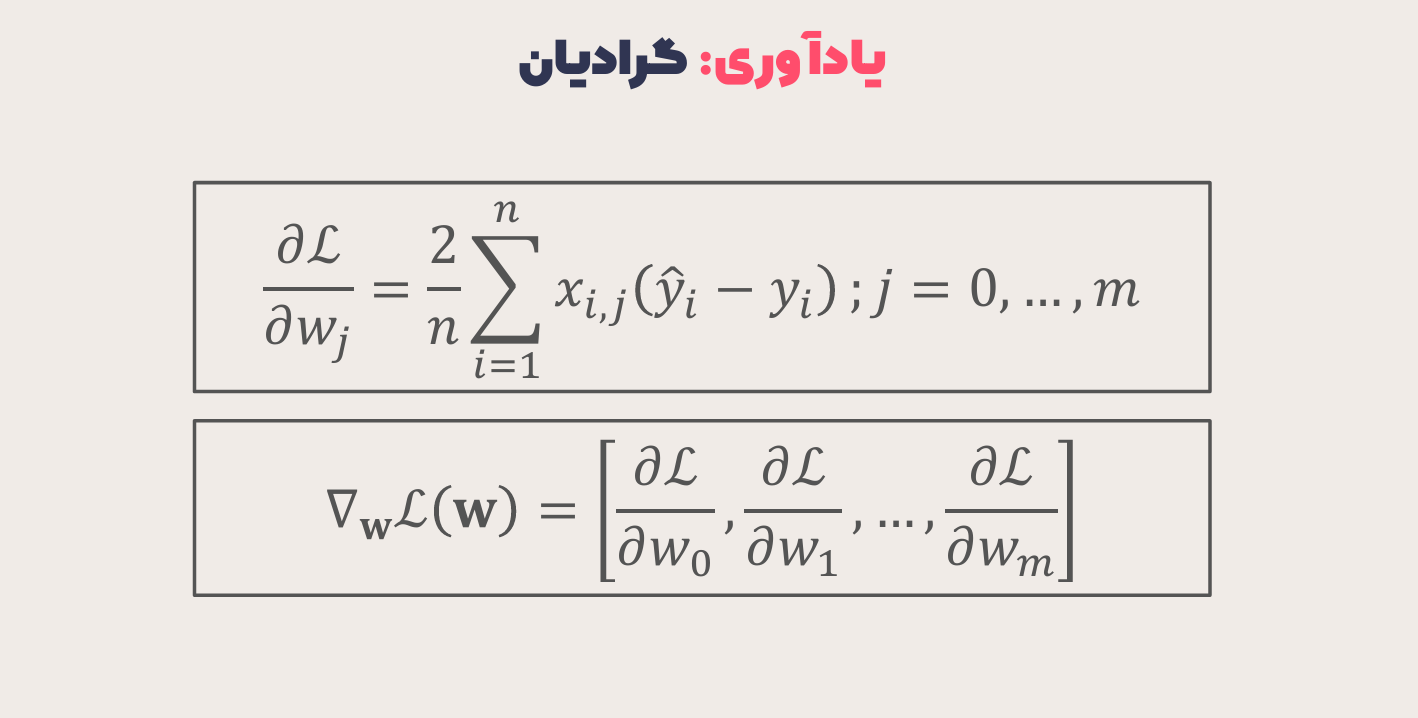

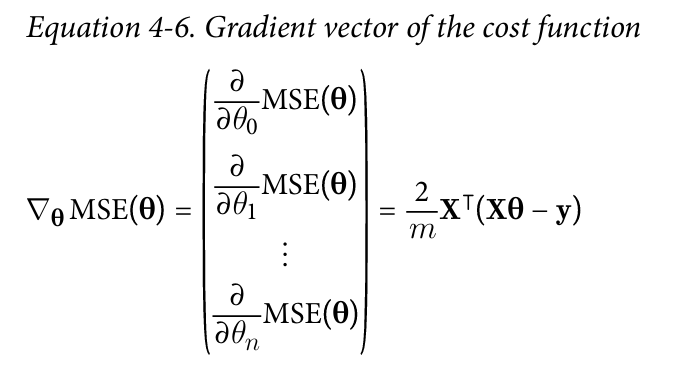

In [13]:
def gradient(x, y, y_hat):
    grads = 2*(x.T @ (y_hat - y)) / x.shape[0]  # (y_hat - y) * x motanazer ba hamun w 
    return grads

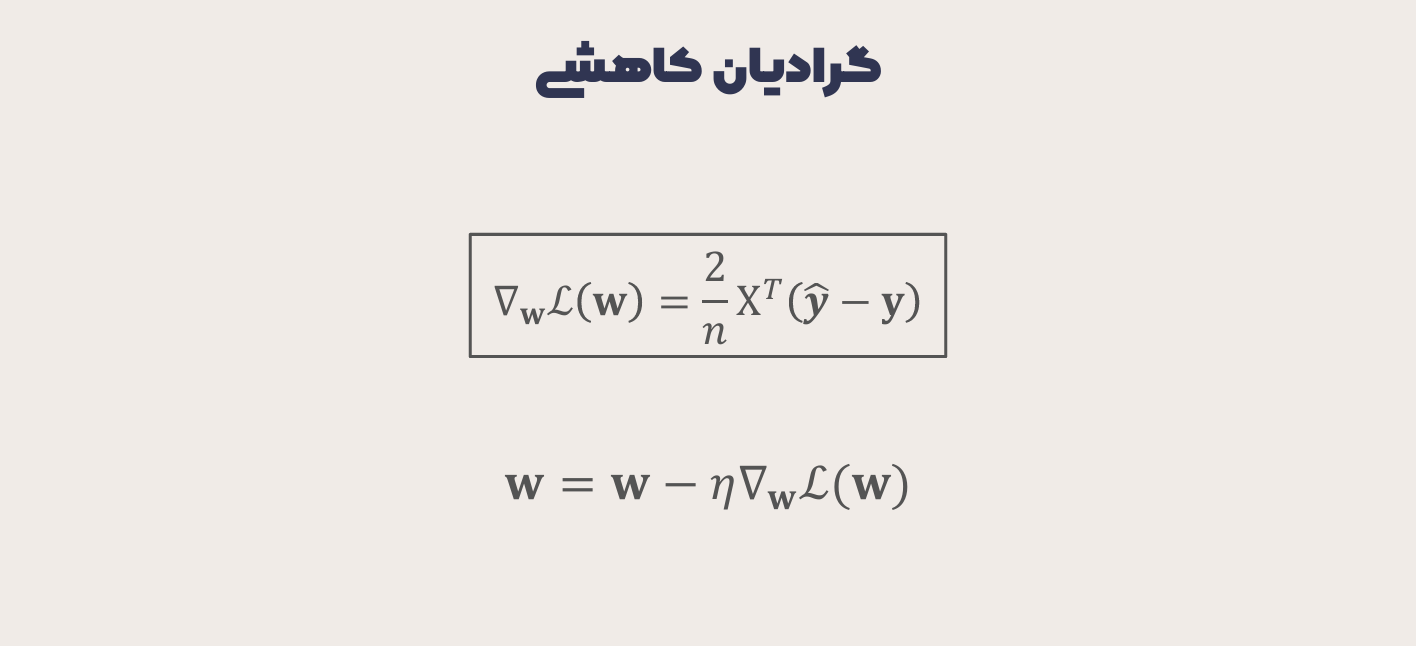

In [14]:
def gradient_descent(w, eta, grads):
    w -= eta*grads
    return w 

### Train

#### - Load Dataset

In [15]:
df = pd.read_csv('data/usa-housing-train-preprocessed.csv')
train_set = np.array(df)[:, 1:]

x_train = train_set[:, 0:5] 
y_train = train_set[:, [5]]

n, m = x_train.shape

# from sklearn.preprocessing import add_dummy_feature 
# x_train = add_dummy_feature(x_train)

x_train = np.hstack((np.ones((n, 1)), x_train))
x_train.shape, y_train.shape  

((3500, 6), (3500, 1))

In [16]:
print(x_train)

[[ 1.         -1.25155908 -2.02901391  1.96206583  0.32306769  0.74505618]
 [ 1.         -0.58905082  0.51802457  0.65581093 -0.64126509  1.09858717]
 [ 1.          0.82222246 -0.5746743   1.24823096 -0.70609418 -0.95283943]
 ...
 [ 1.         -0.22405818  0.53537657 -0.37378791 -0.68178327  0.1133951 ]
 [ 1.         -0.92790309  1.4299047   2.26865538  0.27444587  1.39022039]
 [ 1.         -0.69631047 -0.08161155  0.88764104  1.6682714  -0.01308001]]


#### - Initialization

In [17]:
w = np.random.randn(m+1, 1)
print(w.shape)

eta = 0.01
n_epochs = 2000 # number of iterations 

(6, 1)


#### - Main

In [18]:
error_hist = []

for epoch in range(n_epochs):
    # predictions
    y_hat = multiple_linear_regression(x_train, w)

    # loss
    e = mse(y_train, y_hat)
    error_hist.append(e)
    
    # gradients
    grads = gradient(x_train, y_train, y_hat)
    
    # gradient descent
    w = gradient_descent(w, eta, grads)
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch={epoch}, \t E={e:.4},\t w={w.T[0]}')

Epoch=99, 	 E=0.2347,	 w=[ 0.93357857  0.20376478  0.17982834 -0.10492324  0.33748738 -0.04188957]
Epoch=199, 	 E=0.02279,	 w=[1.1906201  0.22154285 0.16387484 0.02806901 0.10287915 0.12565774]
Epoch=299, 	 E=0.01152,	 w=[1.22562597 0.22774579 0.16336835 0.08802481 0.03652896 0.14790363]
Epoch=399, 	 E=0.01043,	 w=[1.23045944 0.22961146 0.16380434 0.10931756 0.01443251 0.15071878]
Epoch=499, 	 E=0.0103,	 w=[1.23114887 0.23018647 0.16402744 0.11666561 0.00687118 0.15102224]
Epoch=599, 	 E=0.01029,	 w=[1.23125455 0.23037153 0.16411278 0.11919192 0.00427373 0.151035  ]
Epoch=699, 	 E=0.01029,	 w=[1.23127313 0.23043298 0.16414312 0.12006012 0.00338106 0.15102676]
Epoch=799, 	 E=0.01029,	 w=[1.23127712 0.23045375 0.16415366 0.12035849 0.00307427 0.15102218]
Epoch=899, 	 E=0.01029,	 w=[1.23127817 0.23046083 0.16415729 0.12046102 0.00296883 0.15102037]
Epoch=999, 	 E=0.01029,	 w=[1.23127848 0.23046326 0.16415854 0.12049626 0.0029326  0.15101971]
Epoch=1099, 	 E=0.01029,	 w=[1.23127858 0.23046

### Learning curve

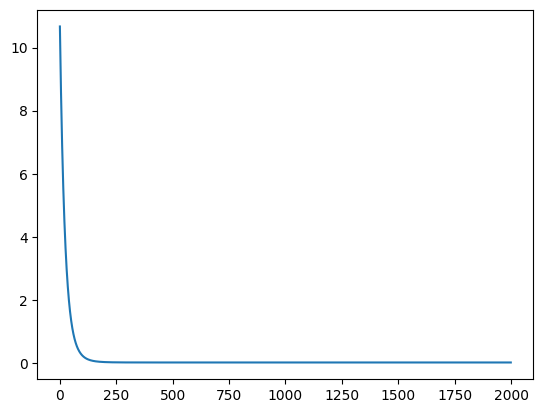

In [19]:
plt.plot(error_hist);

### Save model

In [20]:
np.save('multiple-linear-regression-weights-vec', w)

### Test

In [21]:
df = pd.read_csv('data/usa-housing-test-preprocessed.csv')
test_set = np.array(df)[:, 1:]

x_test = test_set[:, 0:5]
y_test = test_set[:, [5]]

n, m = x_test.shape
x_test = np.hstack((np.ones((n, 1)), x_test))
x_test.shape, y_test.shape

((1500, 6), (1500, 1))

In [22]:
y_hat_test = multiple_linear_regression(x_test, w)
y_hat_test.shape

(1500, 1)

In [23]:
mae(y_test, y_hat_test)

0.08113556609188413

In [24]:
r2(y_test, y_hat_test) 

0.9146818498696061

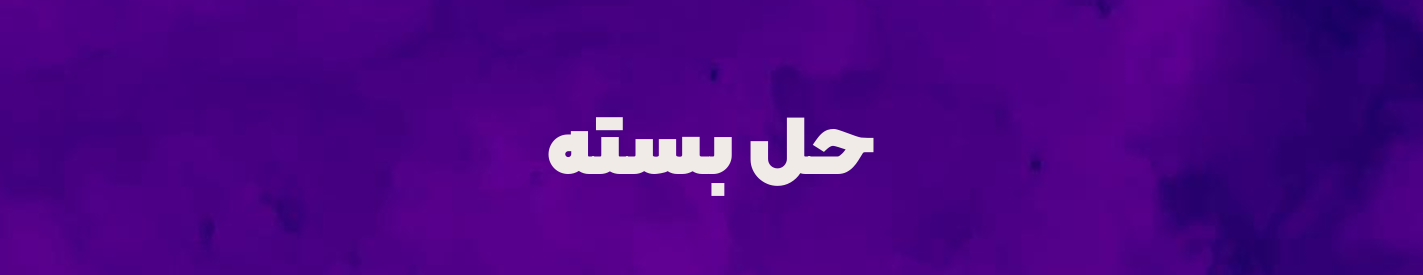

## **🔸 Closed-form Solution**
## **just for linear**

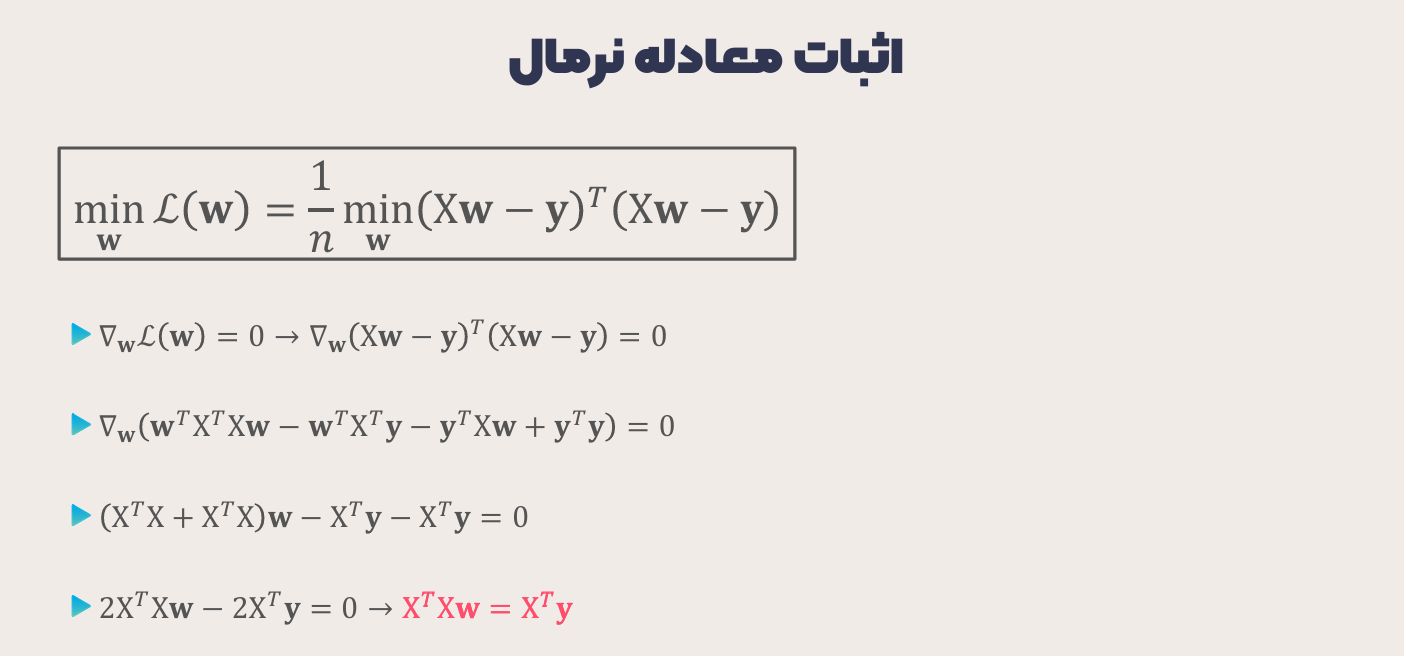

$
\begin{align}
w &= (X^TX)^{-1} X^T y
\end{align}
$

In [25]:
df = pd.read_csv('data/usa-housing-train-preprocessed.csv')
train_set = np.array(df)[:, 1:]

x_train = train_set[:, 0:5]
y_train = train_set[:, [5]]

n, m = x_train.shape
x_train = np.hstack((np.ones((n, 1)), x_train))
x_train.shape, y_train.shape 

((3500, 6), (3500, 1))

In [26]:
X = x_train.copy()
y = y_train.copy()
X.shape, y.shape

((3500, 6), (3500, 1))

In [27]:
wc = np.linalg.inv(X.T @ X) @ X.T @ y
print(wc)
print(w) 

[[1.23127864]
 [0.23046453]
 [0.1641592 ]
 [0.12051471]
 [0.00291362]
 [0.15101936]]
[[1.23127864]
 [0.23046453]
 [0.1641592 ]
 [0.12051471]
 [0.00291362]
 [0.15101936]]


### Test

In [28]:
df = pd.read_csv('data/usa-housing-test-preprocessed.csv')
test_set = np.array(df)[:, 1:]

x_test = test_set[:, 0:5]
y_test = test_set[:, [5]]

n, m = x_test.shape
x_test = np.hstack((np.ones((n, 1)), x_test))
x_test.shape, y_test.shape

((1500, 6), (1500, 1))

In [29]:
y_hat_test = multiple_linear_regression(x_test, wc)
y_hat_test.shape

(1500, 1)

In [30]:
print(mae(y_test, y_hat_test))
print(r2(y_test, y_hat_test)) 

0.08113556608241772
0.9146818498916267


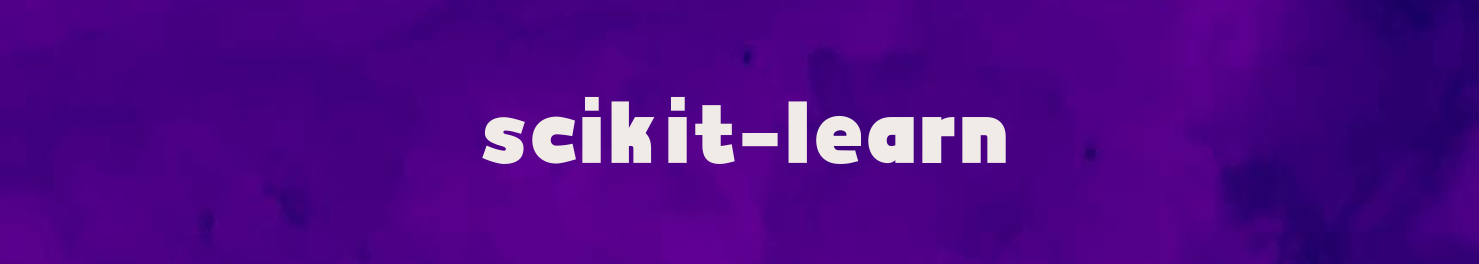

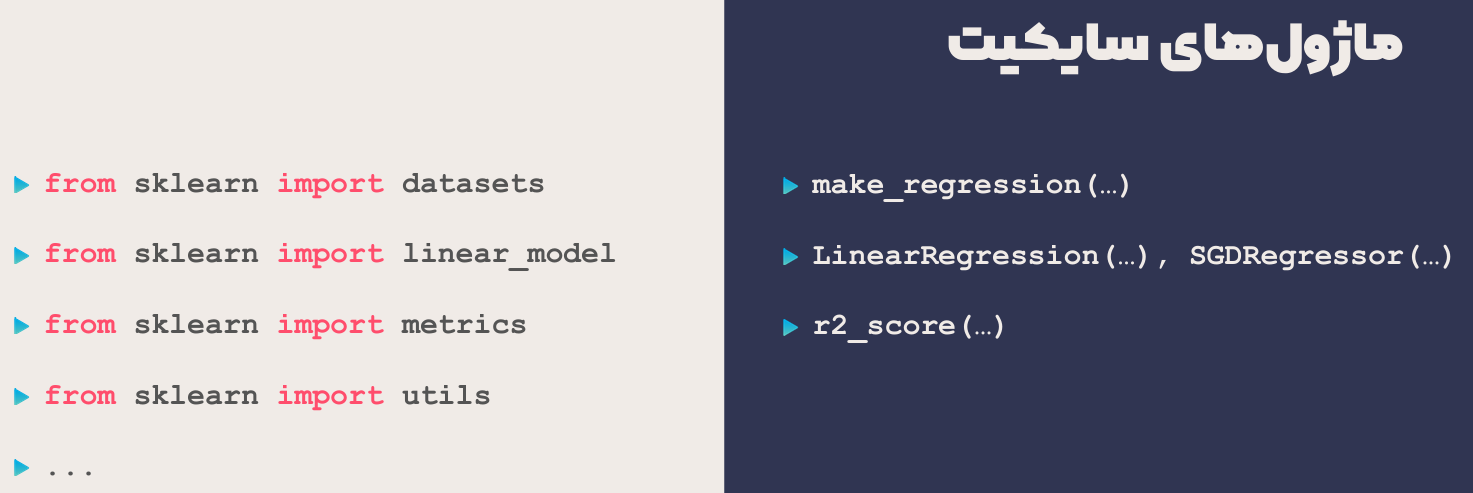

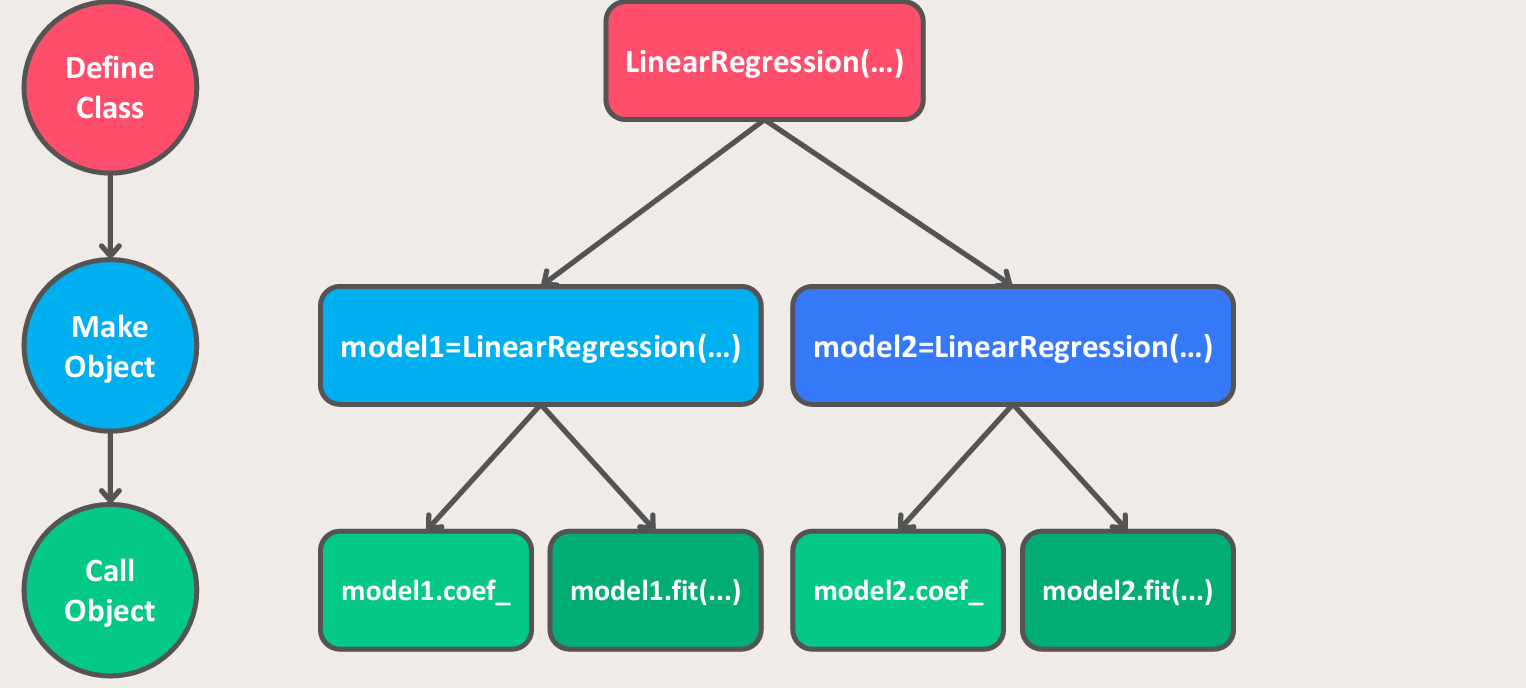

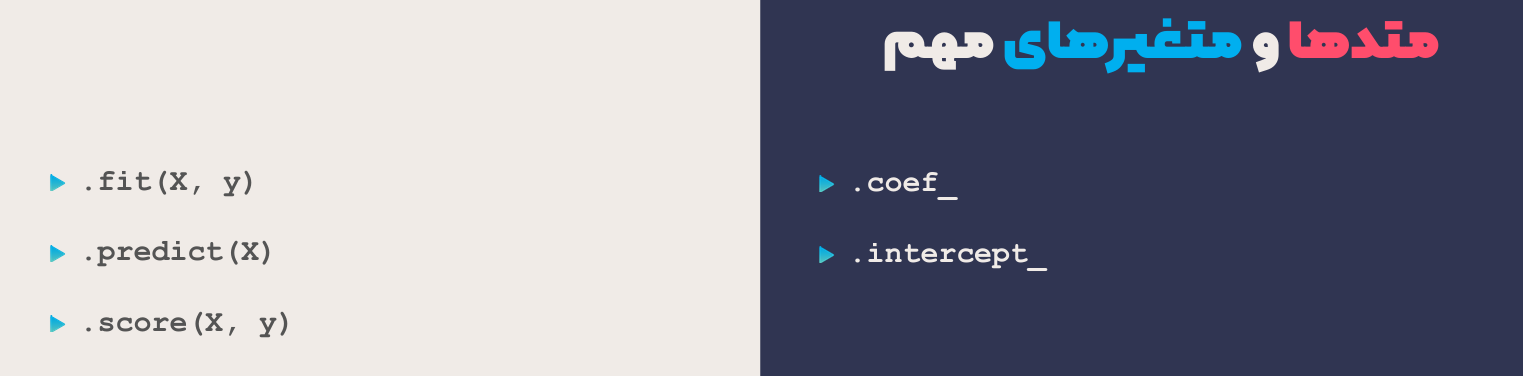

## **🔸 scikit-learn: LinearRegression()**

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

### Train Dataset

In [31]:
df = pd.read_csv('data/usa-housing-train-preprocessed.csv')
train_set = np.array(df)[:, 1:]

x_train = train_set[:, 0:5]
y_train = train_set[:, [5]]

n, m = x_train.shape
x_train = np.hstack((np.ones((n, 1)), x_train))
x_train.shape, y_train.shape

((3500, 6), (3500, 1))

### Test Dataset

In [32]:
df = pd.read_csv('data/usa-housing-test-preprocessed.csv')
test_set = np.array(df)[:, 1:]

x_test = test_set[:, 0:5]
y_test = test_set[:, [5]]

n, m = x_test.shape
x_test = np.hstack((np.ones((n, 1)), x_test))
x_test.shape, y_test.shape  

((1500, 6), (1500, 1))

### Model

In [33]:
model = LinearRegression()
model 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
model.coef_, model.rank_   # !!! 

AttributeError: 'LinearRegression' object has no attribute 'coef_'

### Train

In [35]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Rank:", model.rank_) 

Coefficients: [[0.         0.23046453 0.1641592  0.12051471 0.00291362 0.15101936]]
Intercept: [1.23127864]
Rank: 5


### Test

In [37]:
print("Training R²:", model.score(x_train, y_train))
print("Testing R²:", model.score(x_test, y_test))

Training R²: 0.9192986579053273
Testing R²: 0.9146818498916266


In [38]:
y_hat = model.predict(x_test[[0], :])
print("Predicted price:", y_hat)
print("Actual price:", y_test[0])  

Predicted price: [[1.30853614]]
Actual price: [1.33909608]


## **🔸 scikit-learn: SGDRegressor()**

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html

### Train Dataset

In [39]:
df = pd.read_csv('data/usa-housing-train-preprocessed.csv')
train_set = np.array(df)[:, 1:]

x_train = train_set[:, 0:5]
y_train = train_set[:, 5]

n, m = x_train.shape
x_train = np.hstack((np.ones((n, 1)), x_train))
x_train.shape, y_train.shape

((3500, 6), (3500,))

### Test Dataset

In [40]:
df = pd.read_csv('data/usa-housing-test-preprocessed.csv')
test_set = np.array(df)[:, 1:]

x_test = test_set[:, 0:5]
y_test = test_set[:, 5]

n, m = x_test.shape
x_test = np.hstack((np.ones((n, 1)), x_test))
x_test.shape, y_test.shape

((1500, 6), (1500,))

### Model

In [41]:
model = SGDRegressor(verbose=1, eta0=0.1, tol=1e-5)
model

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,1e-05
,shuffle,True
,verbose,1
,epsilon,0.1
,random_state,None


### Train

In [42]:
model.fit(x_train, y_train)

-- Epoch 1
Norm: 0.71, NNZs: 6, Bias: 0.625356, T: 3500, Avg. loss: 0.006543
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.70, NNZs: 6, Bias: 0.612530, T: 7000, Avg. loss: 0.005367
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.70, NNZs: 6, Bias: 0.616932, T: 10500, Avg. loss: 0.005349
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.70, NNZs: 6, Bias: 0.624489, T: 14000, Avg. loss: 0.005338
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.71, NNZs: 6, Bias: 0.627960, T: 17500, Avg. loss: 0.005286
Total training time: 0.01 seconds.
-- Epoch 6
Norm: 0.70, NNZs: 6, Bias: 0.626199, T: 21000, Avg. loss: 0.005315
Total training time: 0.01 seconds.
-- Epoch 7
Norm: 0.70, NNZs: 6, Bias: 0.623789, T: 24500, Avg. loss: 0.005334
Total training time: 0.01 seconds.
-- Epoch 8
Norm: 0.70, NNZs: 6, Bias: 0.623873, T: 28000, Avg. loss: 0.005291
Total training time: 0.01 seconds.
-- Epoch 9
Norm: 0.70, NNZs: 6, Bias: 0.629016, T: 31500, Avg. loss: 0.005297
Total training time:

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,1e-05
,shuffle,True
,verbose,1
,epsilon,0.1
,random_state,None


In [43]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_) 

Intercept: [0.62508629]
Coefficients: [ 6.04298930e-01  2.30689469e-01  1.62467432e-01  1.13198950e-01
 -4.73058502e-05  1.59375146e-01]


### Test

In [44]:
model.score(x_train, y_train)

0.9180432734415058

In [45]:
model.score(x_test, y_test)

0.9130784988334881

In [ ]:
y_hat = model.predict(x_test[[0], :])
y_hat

array([1.31691727])

# https://github.com/ageron/handson-ml3/blob/main/01_the_machine_learning_landscape.ipynb